# Output data integrity checks: tas, tasmax, tasmin

From issue #450
```
there are no nans in the output
no time slices are exactly the same
output variables are within broadly reasonable ranges (same as the input data checks in Add input data checks #316)
```

Four checks against the consolidated output store, one section each:

`
1. **No NaNs beyond the static edge cells**
2. **No duplicate time slices**
3. **Reasonable ranges** (`VAR_SPATIAL_RANGES` in `srm.qaqc`, same bounds as the input checks in #316)
4. **Within input time bounds** (`resolve_member_time_bounds`)


In [1]:
import dask
import zarr 
import pandas as pd
import xarray as xr
import icechunk 
from srm.config import _icechunk_storage_for_path

from srm.qaqc import VAR_SPATIAL_RANGES
from srm.validation import _open_output_datatree, resolve_member_time_bounds
import zarr
zarr.config.set({"async.concurrency": 128})


In [2]:
import os
os.environ["FRISKY_SUMMARY"] = "off"

from dask_array.xarray import register
from distributed import Client
from frisky import hijack

register()
client = hijack(Client(n_workers=16))
client

<frisky.Client: scheduler="127.0.0.1:44191" id="client-0">

In [3]:
STORE_URI = (
    "s3://carbonplan-scratch/srm/outputs/qa/CESM2-WACCM-ERA5-lat-35.0to-22.0_lon16.0to33.0.icechunk"
)



repo = icechunk.Repository.open(
 _icechunk_storage_for_path("s3://carbonplan-srm/output/production/CESM2-WACCM-ERA5-global.icechunk")
)

session = repo.readonly_session('v0.10.0')

tree = xr.open_datatree(session.store, engine='zarr', chunks='auto')


BRANCH = "main"
GCM = "CESM2-WACCM"
VARIABLES = ["tas", "tasmax"]# "tasmin"]
SPATIAL = ["lat", "lon"]

# Subset configs select slightly more area than the data covers, leaving static all-NaN edge
# cells. Set False for a global run, where check 1 then requires zero NaNs of any kind.
ALLOW_STATIC_NAN_CELLS = False

# On-disk group name -> canonical scenario name used by resolve_member_time_bounds.
GROUP_TO_SCENARIO = {
    "historical": "historical",
    "ssp245": "SSP245", "g6_1p5k": "G6-1.5K"}


# One lazy DataArray per (scenario, variable, member). Members stay separate rows: within a
# scenario they can span different time ranges (some CESM2 SSP245 members end 2070, others
# 2100), so stacking them along an ensemble_member dim would pad NaNs and break check 1.
leaves = {
    (s, v, m): tree[f"{s}/{v}/{m}"].dataset[v]
    for s in GROUP_TO_SCENARIO
    for v in VARIABLES
    if v in tree[s].children
    for m in tree[s][v].children
}


def table(rows: dict) -> pd.DataFrame:
    """One row per leaf, indexed (scenario, variable, member)."""
    return pd.DataFrame.from_dict(rows, orient="index").rename_axis(
        ["scenario", "variable", "member"]
    )


print(f"{len(leaves)} (scenario, variable, member) leaves to check")

13 (scenario, variable, member) leaves to check


In [4]:
da = tree['historical']['tasmax']['001']['tasmax']

In [5]:
import numpy as np
import pandas as pd
import xarray as xr


def nan_report(da: xr.DataArray, time_dim: str = "time") -> dict:
  """NaN summary for one DataArray: totals, static vs partial cells, worst timestep."""
  nan = da.isnull()
  static = nan.all(time_dim)          # cell NaN on every step
  partial = nan.any(time_dim) & ~static  # cell NaN on some-but-not-all steps

  total_cells = int(np.prod([da.sizes[d] for d in da.dims if d != time_dim]))
  per_step_count = nan.sum(dim=[d for d in da.dims if d != time_dim]).compute()

  report = {
      "total_pct_nan": float(nan.mean().compute()) * 100,
      "n_static_cells": int(static.sum().compute()),
      "n_partial_cells": int(partial.sum().compute()),
      "static_pct_of_grid": int(static.sum().compute()) / total_cells * 100,
      "worst_timestep": per_step_count.idxmax(time_dim).values,
      "worst_timestep_n_nan": int(per_step_count.max()),
      "static_mask": static,      # DataArray, for plotting
      "partial_mask": partial,    # DataArray, for plotting
      "per_step_count": per_step_count,  # NaN count per timestep, for a time-series plot
  }
  print(f"total NaN: {report['total_pct_nan']:.3f}%")
  print(f"static cells (NaN every step): {report['n_static_cells']} ({report['static_pct_of_grid']:.2f}% of grid)")
  print(f"partial cells (NaN some steps): {report['n_partial_cells']}")
  print(f"worst timestep: {pd.Timestamp(report['worst_timestep']).date()} ({report['worst_timestep_n_nan']} NaN cells)")
  return report


# usage
r = nan_report(da)  # da: xr.DataArray with a time dim
r

total NaN: 0.278%
static cells (NaN every step): 2884 (0.28% of grid)
partial cells (NaN some steps): 0
worst timestep: 1978-01-01 (2884 NaN cells)


{'total_pct_nan': 0.2777777777777778,
 'n_static_cells': 2884,
 'n_partial_cells': 0,
 'static_pct_of_grid': 0.2777777777777778,
 'worst_timestep': np.datetime64('1978-01-01T00:00:00.000000000'),
 'worst_timestep_n_nan': 2884,
 'static_mask': <xarray.DataArray 'tasmax' (lat: 721, lon: 1440)> Size: 1MB
 dask.array<all, shape=(721, 1440), dtype=bool, chunksize=(32, 64), chunktype=numpy.ndarray>
 Coordinates:
   * lat      (lat) float32 3kB -90.0 -89.75 -89.5 -89.25 ... 89.5 89.75 90.0
   * lon      (lon) float32 6kB -180.0 -179.8 -179.5 -179.2 ... 179.2 179.5 179.8
 Attributes:
     long_name:   Maximum temperature at 2 metres since previous post-processing
     short_name:  mx2t
     units:       K,
 'partial_mask': <xarray.DataArray 'tasmax' (lat: 721, lon: 1440)> Size: 1MB
 dask.array<and, shape=(721, 1440), dtype=bool, chunksize=(32, 64), chunktype=numpy.ndarray>
 Coordinates:
   * lat      (lat) float32 3kB -90.0 -89.75 -89.5 -89.25 ... 89.5 89.75 90.0
   * lon      (lon) float32 6k

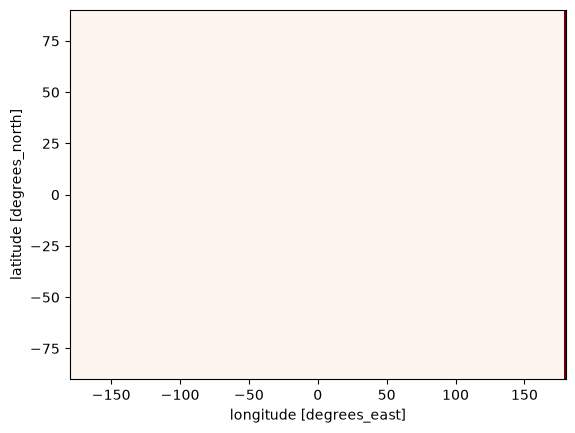

In [6]:

# plot the static mask (fixed geographic pattern)
r["static_mask"].plot(cmap="Reds", add_colorbar=False)

# plot the

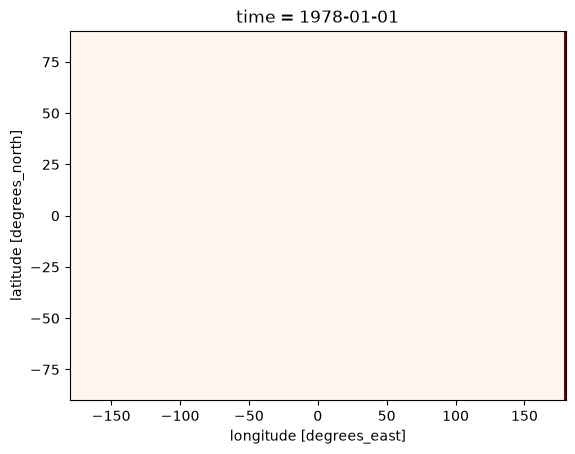

In [8]:
 # worst single timestep's actual NaN footprint (static + any partial hits that day)
da.sel(time=r["worst_timestep"],method='nearest').isnull().plot(cmap="Reds", add_colorbar=False)

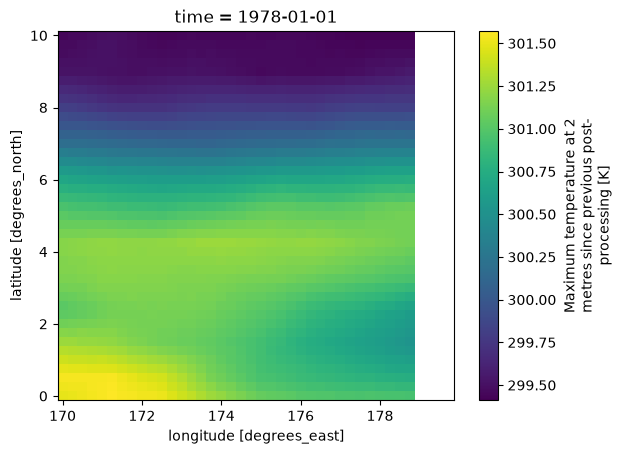

In [13]:
da.isel(time=0).sel(lat = slice(0,10),lon=slice(170,180)).plot()

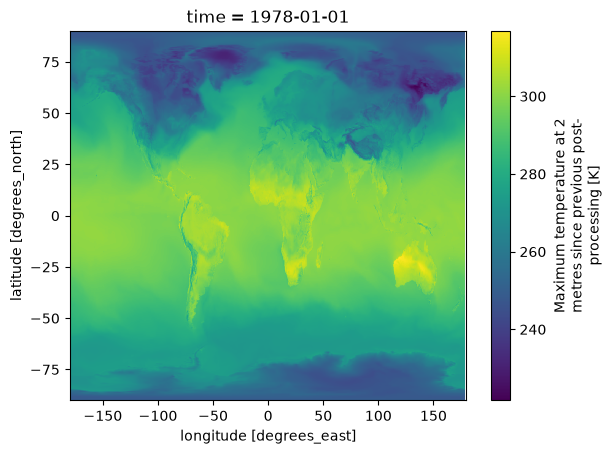

In [14]:
da.isel(time=0).plot()

In [9]:
pd.Timestamp(r["worst_timestep"]).date()

datetime.date(1978, 1, 1)

In [ ]:
tree['historical']['tas']['r1i1p1f1'].isel(time=0).tas.plot()

## Compute all array statistics in one pass

Everything checks 1-3 need per leaf: NaN cell counts, global min/max, and per-day spatial
fingerprints (mean/std/min/max) for the duplicate check. Single batched `dask.compute`.

In [ ]:
def leaf_stats(da: xr.DataArray) -> xr.Dataset:
    nan = da.isnull()
    static = nan.all("time")
    return xr.Dataset(
        {
            "n_static_cells": static.sum(),
            "n_partial_cells": (nan.any("time") & ~static).sum(),
            "min": da.min(),
            "max": da.max(),
            "fingerprint": xr.concat(
                [da.mean(SPATIAL), da.std(SPATIAL), da.min(SPATIAL), da.max(SPATIAL)],
                dim=pd.Index(["mean", "std", "min", "max"], name="stat"),
            ),
        }
    )


(stats,) = dask.compute({key: leaf_stats(da) for key, da in leaves.items()})

## Check 1 -- no NaNs beyond the static edge cells

The South Africa subset config selects slightly more area than the data covers, so a fixed
set of edge cells is NaN on *every* day (static). A cell NaN on some-but-not-all days
(partial) is a data bug -- the stale-tasmin signature on fix-v1/v2/v3.

Pass = zero partial-NaN cells; with `ALLOW_STATIC_NAN_CELLS = False` (global run) static
cells must also be zero, making this the literal no-NaNs check.

In [ ]:
nan_df = table(
    {
        k: {"n_static_cells": int(s.n_static_cells), "n_partial_cells": int(s.n_partial_cells)}
        for k, s in stats.items()
    }
)
nan_df["pass"] = (nan_df.n_partial_cells == 0) & (
    ALLOW_STATIC_NAN_CELLS | (nan_df.n_static_cells == 0)
)
nan_df

## Check 2 -- no duplicate time slices

Two identical days necessarily share a fingerprint, so collisions are a complete candidate
set; each collision is confirmed elementwise (loads only the two candidate slices, and only
when a collision exists).

In [ ]:
def duplicate_pairs(da: xr.DataArray, fp: xr.DataArray) -> list[tuple[str, str]]:
    """Confirmed identical-day pairs: fingerprint collision + exact elementwise equality."""
    df = fp.round(10).to_pandas().T.dropna()  # rows=time, cols=stat; all-NaN days drop out
    collided = df[df.duplicated(keep=False)].groupby(list(df.columns)).groups
    # drop the scalar time coord before comparing -- .equals compares coords too, and the
    # differing time stamps would otherwise mask genuinely identical data
    return [
        (str(times[0])[:10], str(t)[:10])
        for times in collided.values()
        for t in times[1:]
        if da.sel(time=t).drop_vars("time").equals(da.sel(time=times[0]).drop_vars("time"))
    ]


dup_df = table(
    {k: {"duplicate_pairs": duplicate_pairs(leaves[k], s.fingerprint)} for k, s in stats.items()}
)
dup_df["pass"] = dup_df.duplicate_pairs.str.len() == 0
dup_df

## Check 3 -- reasonable ranges

Whole-array min/max per leaf against the `VAR_SPATIAL_RANGES` intervals.

In [ ]:
range_df = table({k: {"min": float(s["min"]), "max": float(s["max"])} for k, s in stats.items()})
range_df["pass"] = [
    VAR_SPATIAL_RANGES[v]["min"][0] <= mn <= VAR_SPATIAL_RANGES[v]["min"][1]
    and VAR_SPATIAL_RANGES[v]["max"][0] <= mx <= VAR_SPATIAL_RANGES[v]["max"][1]
    for (s, v, m), mn, mx in zip(range_df.index, range_df["min"], range_df["max"])
]
range_df

## Check 4 -- within input time bounds

Metadata only, no compute. G6/SAI outputs legitimately start before the raw scenario window --
the pipeline bridges 2015-2035 with SSP245 (`stitch_historical_scenario`), mirroring the
`is_sai_scenario` carve-out in `check_config_time_domain` -- so the start bound is enforced
only for non-SAI scenarios.

In [ ]:
bounds_df = table(
    {
        (s, v, m): {
            "actual_start": str(da.time.values[0])[:10],
            "actual_end": str(da.time.values[-1])[:10],
            "expected": resolve_member_time_bounds(GCM, GROUP_TO_SCENARIO[s], m),
        }
        for (s, v, m), da in leaves.items()
    }
)
expected_start = bounds_df.expected.str[0].fillna("0000-01-01")  # no known bounds -> pass
expected_end = bounds_df.expected.str[1].fillna("9999-12-31")
is_sai = bounds_df.index.get_level_values("scenario").str.upper().str.contains("G6|SAI")
bounds_df["pass"] = (is_sai | (bounds_df.actual_start >= expected_start)) & (
    bounds_df.actual_end <= expected_end
)
bounds_df

## Summary

In [ ]:
summary = pd.concat(
    {
        "no_partial_nans": nan_df["pass"],
        "no_duplicate_timesteps": dup_df["pass"],
        "reasonable_range": range_df["pass"],
        "within_input_time_bounds": bounds_df["pass"],
    },
    axis=1,
)
print(summary.to_string())
print(f"\nAll checks passed across {len(summary)} leaves: {bool(summary.all().all())}")

In [ ]:
client.shutdown()